In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [56]:
df = pd.read_csv('../Data/student_information.csv')

In [57]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0.0,11.0,11.0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9.0,11.0,11.0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12.0,13.0,12.0
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14.0,14.0,14.0
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11.0,13.0,13.0


In [58]:
df.groupby('health').G3.mean()

health
1    12.270073
2    11.471545
3    11.065116
4    11.471264
5    11.073418
Name: G3, dtype: float64

In [59]:
X = df.drop(columns=['G3'], axis=1)
y = df['G3']

In [60]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [61]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [62]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [63]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [65]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

svr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVR())
])

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ))
])

In [66]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [67]:
def evaluate_model(name, pipeline):
    pipeline.fit(x_train, y_train)

    y_pred = pipeline.predict(x_test)

    print(f"--- {name} ---")
    print("R2:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
    print()

In [68]:
evaluate_model("Linear Regression", lr_pipeline)
evaluate_model("Decision Tree", dt_pipeline)
evaluate_model("Random Forest", rf_pipeline)
evaluate_model("Gradient Boosting", gb_pipeline)
evaluate_model("Support Vector Regressor", svr_pipeline)
evaluate_model('XGBoost', xgb_pipeline)

--- Linear Regression ---
R2: 0.8385512666651314
MAE: 1.0018015629062806
RMSE: 1.5345545658941417

--- Decision Tree ---
R2: 0.7014857437037176
MAE: 1.1196172248803828
RMSE: 2.0866401188623622

--- Random Forest ---
R2: 0.8678563432926155
MAE: 0.887842105263158
RMSE: 1.388315508194156

--- Gradient Boosting ---
R2: 0.8746911633602183
MAE: 0.917471438383266
RMSE: 1.3519351624077869

--- Support Vector Regressor ---
R2: 0.7490821190184134
MAE: 1.133492420559657
RMSE: 1.9130698194113789

--- XGBoost ---
R2: 0.8375276503115665
MAE: 0.9933253892799884
RMSE: 1.539411566601954



In [69]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__subsample": [0.8, 1.0],
    "model__loss": ["squared_error", "absolute_error"]
}

In [70]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    gb_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.03, 0.05, ...], 'model__loss': ['squared_error', 'absolute_error'], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the

In [71]:
best_model = grid_search.best_estimator_

print(grid_search.best_params_)
print(grid_search.best_score_)

{'model__learning_rate': 0.03, 'model__loss': 'squared_error', 'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200, 'model__subsample': 1.0}
0.8412291977850241


In [72]:
y_pred = best_model.predict(x_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

R2: 0.8727215696702163
MAE: 0.892721012849015
RMSE: 1.3625185386362229


In [73]:
print(best_model.score(x_test, y_test))

0.8727215696702163


In [74]:
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = best_model.named_steps[
    "model"
].feature_importances_

In [75]:
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

In [76]:
feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

feature_importance_df.head(15)

,feature,importance
14,num__G2,0.880524
12,num__absences,0.061982
13,num__G1,0.042256
5,num__failures,0.004741
11,num__health,0.000986
17,cat__sex_F,0.000939
0,num__age,0.000875
18,cat__sex_M,0.000858
33,cat__Fjob_services,0.000854
8,num__goout,0.000817


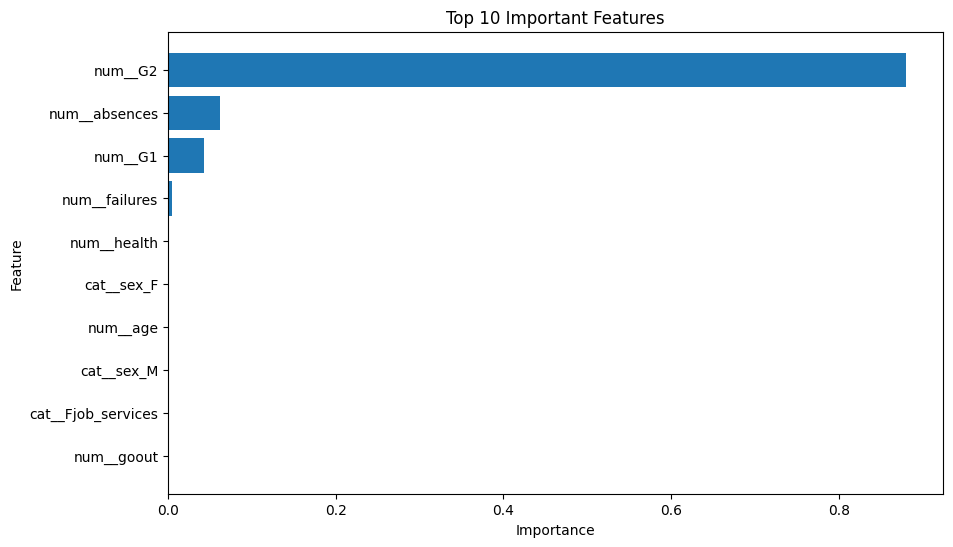

In [77]:
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top 10 Important Features")

plt.show()

In [78]:
import joblib
import os

In [79]:
os.makedirs("models", exist_ok=True)

joblib.dump(
    best_model,
    "models/g3_pipeline.pkl"
)

['models/g3_pipeline.pkl']